# TASKS

----- Linear Regression -----
RMSE = 0.7455813830127751
R² Score = 0.5757877060324521


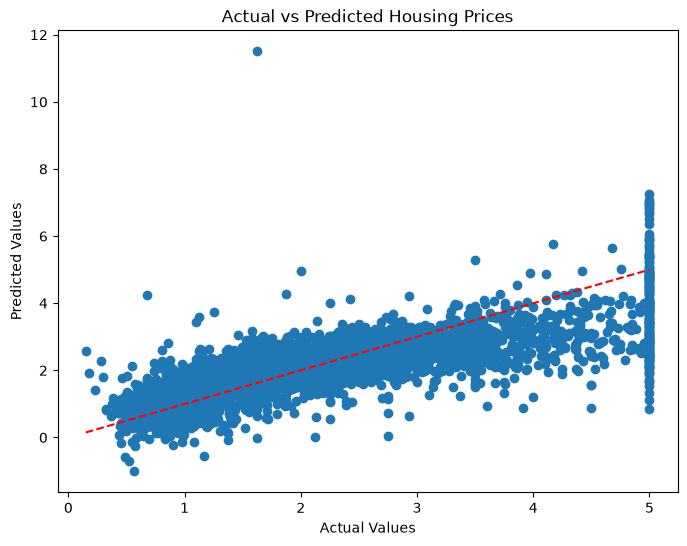


----- Logistic Regression -----

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:
[[20  0]
 [ 0 10]]


In [4]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing, load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix
)

# ==============================
# 1. LINEAR REGRESSION
# ==============================

# Load Housing Dataset
housing = fetch_california_housing()

X = housing.data
y = housing.target

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predictions
y_pred = lr.predict(X_test)

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("----- Linear Regression -----")
print("RMSE =", rmse)
print("R² Score =", r2)

# ==============================
# 4. ACTUAL VS PREDICTED PLOT
# ==============================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Housing Prices")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.show()

# ==============================
# 2. LOGISTIC REGRESSION
# ==============================

# Load Iris Dataset
iris = load_iris()

X = iris.data

# Binary Classification:
# Setosa = 1, Non-Setosa = 0
y = (iris.target == 0).astype(int)

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
log_reg = LogisticRegression(max_iter=200)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)

# ==============================
# 3. CLASSIFICATION REPORT
#    & CONFUSION MATRIX
# ==============================

print("\n----- Logistic Regression -----")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# PRACTICE

In [5]:
# Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Sample Student Data
data = {
    'Hours_Studied': [1,2,3,4,5,6,7,8,9,10,2,3,5,7,8],
    'Pass': [0,0,0,0,1,1,1,1,1,1,0,0,1,1,1]
}

df = pd.DataFrame(data)

X = df[['Hours_Studied']]
y = df['Pass']

# Different Train/Test Ratios
ratios = [0.2, 0.3, 0.4]

for ratio in ratios:
    print("\n" + "="*40)
    print(f"Test Size = {ratio}")
    print("="*40)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=ratio, random_state=42
    )

    model = LogisticRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\nPredictions:")
    for actual, pred in zip(y_test, y_pred):
        print(f"Actual: {actual}, Predicted: {pred}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))


Test Size = 0.2
Accuracy: 1.0

Predictions:
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Test Size = 0.3
Accuracy: 1.0

Predictions:
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Test Size = 0.4